# 3.3 Diffusion in an annular region

## Environment configuration

CPU: 13th Gen Intel(R) Core(TM) i7-13700K 64GB

python==3.13.9 torch==2.9.1

In [1]:
import torch
from cibsde import nn, utils
import matplotlib.pyplot as plt
device = 'cpu'
seed = 666
torch.manual_seed(seed)

## Parameter settings

In [2]:
# model parameters
d = 2
t = torch.tensor([0.25,0.5,0.75,1],device=device)
D = torch.tensor(0.5,device=device)
N = [25,50,75,100]
# training parameters
batch = 512
epoch = 10**4
lr = 1e-3
train_params = {
    'epoch': epoch,
    'batch': batch,
    'lr': lr
}

## Model initialization

In [3]:
def data_gen(batch):
    r = torch.sqrt(torch.rand([batch,1],device=device)*3/4 + 1/4)
    theta = torch.rand([batch,1],device=device)*torch.pi*2
    x = torch.cat([torch.cos(theta),torch.sin(theta)],dim=1)*r
    return x

def pc(i,x):
    return ((x - torch.tensor([0.75,0],device=device)).norm(dim=1,keepdim=True) < 0.25).float()*16/torch.pi

def xb(x):
    xnorm = x.norm(dim=1)
    in_ornot = (xnorm > 0.5)*(xnorm < 1)
    inner = xnorm < 0.75
    xb_ = x / xnorm.unsqueeze(1)
    xb_[inner] = xb_[inner] * 0.5
    n = x / xnorm.unsqueeze(1)
    n[inner] = -n[inner]
    return xb_, n, ~in_ornot

def hit(x):
    return torch.zeros(batch,device=device).bool()

def f(t,xt,p,grad_p):
    return torch.zeros([batch,1],device=device)

def h(t,xt):
    return torch.zeros([xt.shape[0],1],device=device)

def mu(t,xt):
    return torch.zeros([batch,d],device=device)

def sigma(t,xt):
    return torch.eye(d,device=device).expand([batch,d,d]).clone()*torch.sqrt(2*D)

models = [nn.BoundaryIBSDE(
    d = 2,
    t = t[i],
    f = f,
    mu = mu,
    sigma = sigma,
    h = h,
    pc = pc,
    data_gen = data_gen,
    N = N[i],
    refb=xb,
    hitb=hit,
    param=False
).to(device) for i in range(4)]

## Model training

In [4]:
loss_values = [nn.train(
    model,
    train_params
) for model in models]

100%|██████████| 10000/10000 [04:36<00:00, 36.17it/s, loss=5.628847e-01]



Training has been completed.


100%|██████████| 10000/10000 [09:00<00:00, 18.50it/s, loss=6.445796e-01]



Training has been completed.


100%|██████████| 10000/10000 [13:20<00:00, 12.49it/s, loss=5.291343e-01]



Training has been completed.


100%|██████████| 10000/10000 [18:10<00:00,  9.17it/s, loss=4.248587e-01]


Training has been completed.


## PINN

In [5]:
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.p = utils.FNN(3,1)
    
    def forward(self, batch):
        r = torch.sqrt(torch.rand([batch,1],device=device) * 3/4 + 1/4)
        theta = torch.rand([batch,1],device=device)*torch.pi*2
        x = torch.cat([torch.cos(theta),torch.sin(theta)],dim=1)*r
        x.requires_grad = True
        t = torch.rand([batch,1],requires_grad=True,device=device)

        r1 = torch.ones([batch,1],device=device) * 0.5
        r2 = torch.ones([batch*2,1],device=device)
        r1.requires_grad = True
        r2.requires_grad = True
        theta1 = torch.rand([batch,1],device=device)*torch.pi*2
        xb1 = torch.cat([torch.cos(theta1),torch.sin(theta1)],dim=1)*r1
        theta2 = torch.rand([batch*2,1],device=device)*torch.pi*2
        xb2 = torch.cat([torch.cos(theta2),torch.sin(theta2)],dim=1)*r2
        tb1 = torch.rand([batch,1],device=device)
        tb2 = torch.rand([batch*2,1],device=device)

        T = torch.ones([batch,1],device=device)
        u = self.p(torch.cat([t,x],dim=1))
        grad_u = torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        grad_u1 = torch.autograd.grad(grad_u[:,:1],x,torch.ones_like(grad_u[:,:1]),retain_graph=True,create_graph=True)[0][:,:1]
        grad_u2 = torch.autograd.grad(grad_u[:,1:],x,torch.ones_like(grad_u[:,1:]),retain_graph=True,create_graph=True)[0][:,1:]
        ut = torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]

        ub1 = self.p(torch.cat([tb1,xb1],dim=1))
        grad_ub1 = torch.autograd.grad(ub1,r1,torch.ones_like(ub1),retain_graph=True,create_graph=True)[0]
        ub2 = self.p(torch.cat([tb2,xb2],dim=1))
        grad_ub2 = torch.autograd.grad(ub2,r2,torch.ones_like(ub2),retain_graph=True,create_graph=True)[0]

        grad_ub = torch.cat([grad_ub1,grad_ub2])
        uT = self.p(torch.cat([T,x],dim=1))
        return torch.cat([ut,grad_ub,uT]), torch.cat([-D*(grad_u1+grad_u2),torch.zeros_like(grad_ub,device=device),pc(100,x)])

## PINN initialization

In [6]:
pinn = PINN().to(device)

## PINN training

In [7]:
loss_value_pinn = nn.train(
    pinn,
    train_params
)

  0%|          | 0/10000 [00:00<?, ?it/s, loss=4.316414e-01]

100%|██████████| 10000/10000 [01:35<00:00, 104.91it/s, loss=1.108300e-01]


Training has been completed.


## Loading reference solution

In [8]:
y_rel = torch.load('./datasets/example3.pth')

## Plot figures

In [9]:
r = torch.linspace(0.5,1,100)
theta = torch.linspace(0,torch.pi*2,200)
r, theta = torch.meshgrid(r,theta,indexing='ij')
x = torch.stack([torch.cos(theta),torch.sin(theta)],dim=2)*r[:,:,None]
tt = torch.ones([4,100*200,1]) * (1-t[:,None,None])
y_pinn = [pinn.p(torch.cat([tt[i],x.reshape(100*200,2)],dim=1).to(device)).cpu().detach().reshape(100,200) for i in range(4)]
y_pre = [model.p(x.to(device).reshape(100*200,2)).cpu().detach().reshape(100,200) for model in models]

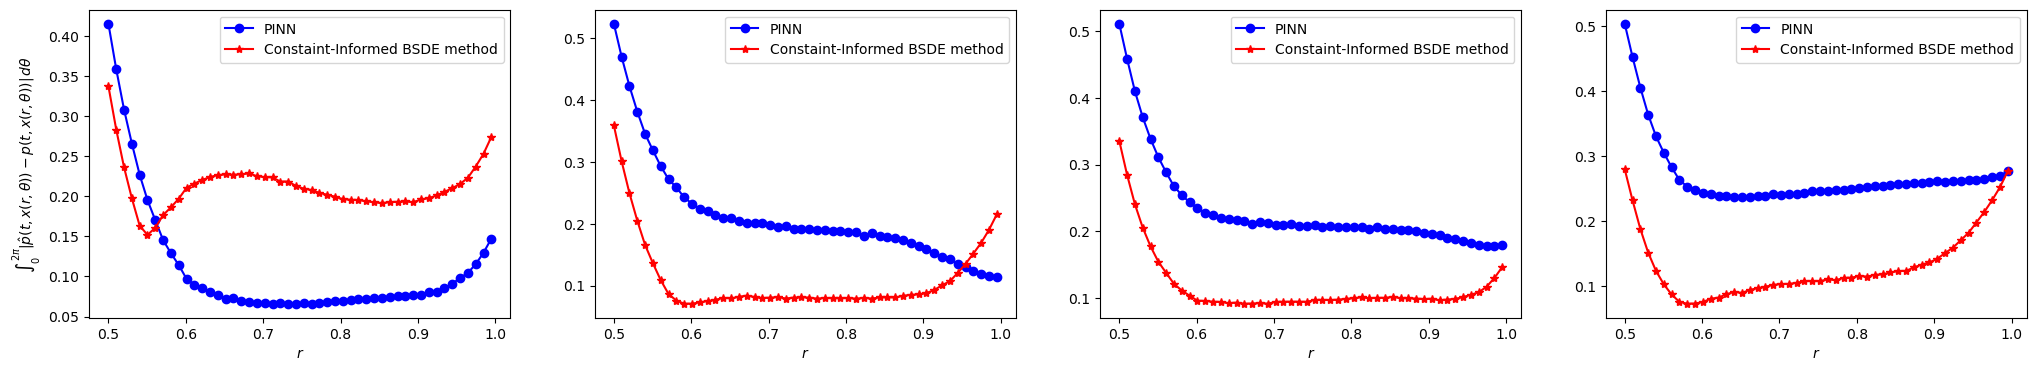

In [10]:
plt.figure(figsize=(25,4))
plt.subplot(1,4,1)
error_pinn = (y_pinn[0]-y_rel[0]).abs()
error_cibsde = (y_pre[0]-y_rel[0]).abs()
plt.xlabel(r'$r$')
plt.ylabel(r"$\int_{0}^{2\pi}|\hat{p}(t,x(r,\theta))-p(t,x(r,\theta))|\,d\theta$")
plt.plot(torch.linspace(0.5,1,100)[::2],error_pinn.mean(dim=-1).detach()[::2]*2*torch.pi,'o-',c='b',label='PINN')
plt.plot(torch.linspace(0.5,1,100)[::2],error_cibsde.mean(dim=-1).detach()[::2]*2*torch.pi,'*-',c='r',label='Constaint-Informed BSDE method')
plt.legend()
plt.subplot(1,4,2)
error_pinn = (y_pinn[1]-y_rel[1]).abs()
error_cibsde = (y_pre[1]-y_rel[1]).abs()
plt.xlabel(r'$r$')
plt.plot(torch.linspace(0.5,1,100)[::2],error_pinn.mean(dim=-1).detach()[::2]*2*torch.pi,'o-',c='b',label='PINN')
plt.plot(torch.linspace(0.5,1,100)[::2],error_cibsde.mean(dim=-1).detach()[::2]*2*torch.pi,'*-',c='r',label='Constaint-Informed BSDE method')
plt.legend()
plt.subplot(1,4,3)
error_pinn = (y_pinn[2]-y_rel[2]).abs()
error_cibsde = (y_pre[2]-y_rel[2]).abs()
plt.xlabel(r'$r$')
plt.plot(torch.linspace(0.5,1,100)[::2],error_pinn.mean(dim=-1).detach()[::2]*2*torch.pi,'o-',c='b',label='PINN')
plt.plot(torch.linspace(0.5,1,100)[::2],error_cibsde.mean(dim=-1).detach()[::2]*2*torch.pi,'*-',c='r',label='Constaint-Informed BSDE method')
plt.legend()
plt.subplot(1,4,4)
error_pinn = (y_pinn[3]-y_rel[3]).abs()
error_cibsde = (y_pre[3]-y_rel[3]).abs()
plt.xlabel(r'$r$')
plt.plot(torch.linspace(0.5,1,100)[::2],error_pinn.mean(dim=-1).detach()[::2]*2*torch.pi,'o-',c='b',label='PINN')
plt.plot(torch.linspace(0.5,1,100)[::2],error_cibsde.mean(dim=-1).detach()[::2]*2*torch.pi,'*-',c='r',label='Constaint-Informed BSDE method')
plt.legend()
from matplotlib.transforms import Bbox
custom_bbox = Bbox([[2, -0.5], [23,4]])
plt.savefig('./figures/euclid_complex_err_r.pdf', bbox_inches=custom_bbox, dpi=2000, format='pdf')
plt.show()

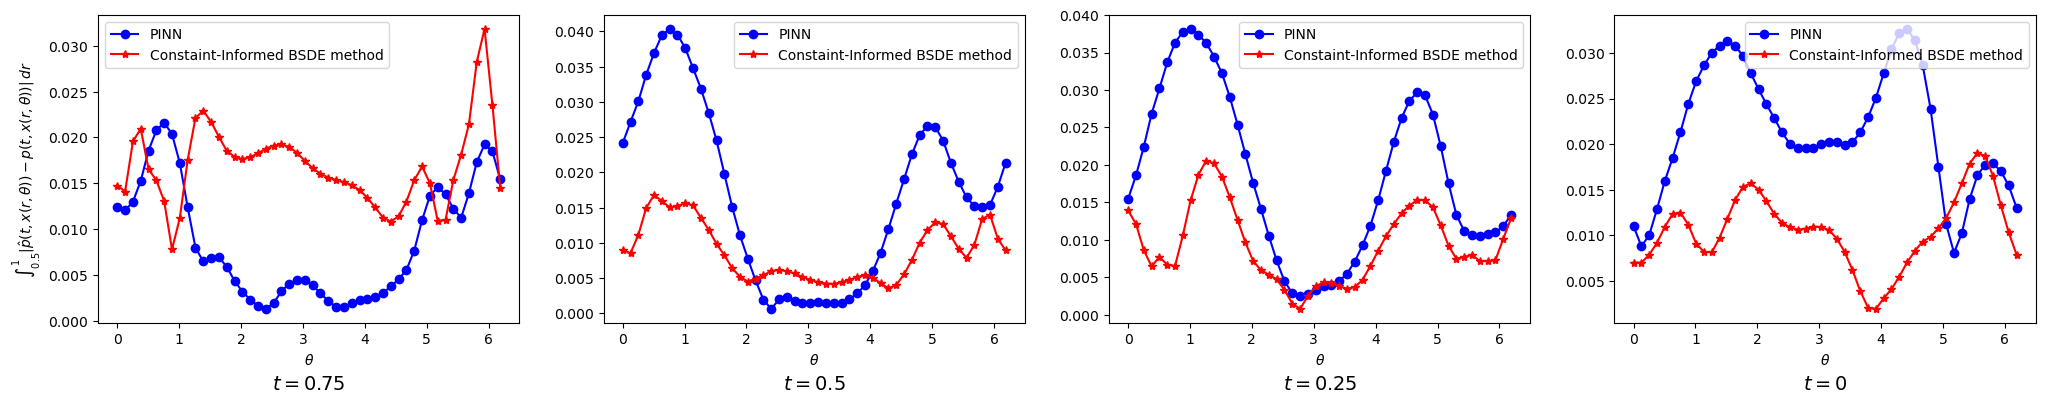

In [11]:
plt.figure(figsize=(25,4))
plt.subplot(1,4,1)
error_pinn = (y_pinn[0]-y_rel[0]).abs()
error_cibsde = (y_pre[0]-y_rel[0]).abs()
plt.xlabel(r'$\theta$')
plt.ylabel(r"$\int_{0.5}^{1}|\hat{p}(t,x(r,\theta))-p(t,x(r,\theta))|\,dr$")
plt.plot(torch.linspace(0,2*torch.pi,200)[::4],error_pinn.mean(dim=-2).detach()[::4]*0.5,'o-',c='b',label='PINN')
plt.plot(torch.linspace(0,2*torch.pi,200)[::4],error_cibsde.mean(dim=-2).detach()[::4]*0.5,'*-',c='r',label='Constaint-Informed BSDE method')
plt.text(0.5, -0.2, '$t=0.75$',transform=plt.gca().transAxes,fontsize=14,va='center',ha='center') 
plt.legend()
plt.subplot(1,4,2)
error_pinn = (y_pinn[1]-y_rel[1]).abs()
error_cibsde = (y_pre[1]-y_rel[1]).abs()
plt.xlabel(r'$\theta$')
plt.plot(torch.linspace(0,2*torch.pi,200)[::4],error_pinn.mean(dim=-2).detach()[::4]*0.5,'o-',c='b',label='PINN')
plt.plot(torch.linspace(0,2*torch.pi,200)[::4],error_cibsde.mean(dim=-2).detach()[::4]*0.5,'*-',c='r',label='Constaint-Informed BSDE method')
plt.text(0.5, -0.2, '$t=0.5$',transform=plt.gca().transAxes,fontsize=14,va='center',ha='center')
plt.legend()
plt.subplot(1,4,3)
error_pinn = (y_pinn[2]-y_rel[2]).abs()
error_cibsde = (y_pre[2]-y_rel[2]).abs()
plt.xlabel(r'$\theta$')
plt.plot(torch.linspace(0,2*torch.pi,200)[::4],error_pinn.mean(dim=-2).detach()[::4]*0.5,'o-',c='b',label='PINN')
plt.plot(torch.linspace(0,2*torch.pi,200)[::4],error_cibsde.mean(dim=-2).detach()[::4]*0.5,'*-',c='r',label='Constaint-Informed BSDE method')
plt.text(0.5, -0.2, '$t=0.25$',transform=plt.gca().transAxes,fontsize=14,va='center',ha='center')
plt.legend()
plt.subplot(1,4,4)
error_pinn = (y_pinn[3]-y_rel[3]).abs()
error_cibsde = (y_pre[3]-y_rel[3]).abs()
plt.xlabel(r'$\theta$')
plt.plot(torch.linspace(0,2*torch.pi,200)[::4],error_pinn.mean(dim=-2).detach()[::4]*0.5,'o-',c='b',label='PINN')
plt.plot(torch.linspace(0,2*torch.pi,200)[::4],error_cibsde.mean(dim=-2).detach()[::4]*0.5,'*-',c='r',label='Constaint-Informed BSDE method')
plt.text(0.5, -0.2, '$t=0$',transform=plt.gca().transAxes,fontsize=14,va='center',ha='center')
plt.legend()
from matplotlib.transforms import Bbox
custom_bbox = Bbox([[2, -0.5], [23,4]])
plt.savefig('./figures/euclid_complex_err_theta.pdf', bbox_inches=custom_bbox, dpi=2000, format='pdf')
plt.show()

## Relative L2 errors

In [12]:
error_pinn = []
error_cibsde = []
for i in range(4):
    error_pinn.append(torch.sqrt(((y_pinn[i]-y_rel[i])**2).mean() / ((y_rel[i])**2).mean()))
    error_cibsde.append(torch.sqrt(((y_pre[i]-y_rel[i])**2).mean() / ((y_rel[i])**2).mean()))
print('Relative L2 errors \n', 'PINN: ', error_pinn, '\n', 'Ours: ', error_cibsde)

Relative L2 errors 
 PINN:  [tensor(0.0422), tensor(0.0798), tensor(0.0880), tensor(0.0964)] 
 Ours:  [tensor(0.0553), tensor(0.0428), tensor(0.0483), tensor(0.0525)]
